# Forecasting Electricity Demand: A Complete Machine Learning Project Tutorial

In this notebook I build a model predicting hourly electricity demand
(`Consumption`, megawatts) for Romania's national grid, using real,
published data from 2019 onward — plus its generation mix (nuclear,
wind, hydro, oil & gas, coal, solar, biomass), which turns out to
matter more than I expected going in.

## Why this project, and why this dataset

I picked demand forecasting as a deliberately different kind of
project from the rest of this portfolio — every other project treats
each row as independent and asks "what class is this?". This one is a
**time series**: the order of the rows *is* the problem, and getting
the train/test split wrong here creates a much sneakier kind of data
leakage than a shuffle-based split would elsewhere.

I originally built this project on US grid data (PJM Interconnection),
then switched to this Romanian dataset instead, specifically because
the generation-mix breakdown (how much of each hour's electricity came
from nuclear vs. wind vs. solar vs. coal) is genuinely useful,
interesting data I didn't have before — it lets me ask questions a
plain demand series can't answer, like whether recent generation mix
carries any signal about upcoming demand, and it comes with its own
real energy-transition story (solar generation roughly doubled between
2023 and 2025).

One thing worth knowing upfront: **this dataset is live and
continuously updated**, unlike every other dataset in this portfolio. I
checked directly — an earlier download had 46,002 rows through April
2024; the version I actually used has 62,810 rows through March 2026,
with the older rows unchanged. Every number in this notebook reflects
the snapshot I downloaded, not a fixed, versioned file — worth flagging
plainly rather than implying this is as reproducible as a frozen CSV.

I still couldn't find a real, public, hourly demand dataset for
Vietnam's own grid (checked directly — EVN's public releases are highly
aggregated). Romania's data is a genuinely different climate and market
structure than Vietnam's, but grid-scale hourly demand forecasting is
the same *kind* of problem regardless of country, and — as I found out
below — Romania's own generation mix (with a growing renewable share)
raises questions increasingly relevant to Vietnam's own energy
transition too.

## What I set out to learn

1. **Time-series-specific data cleaning**: the same kind of Daylight
   Saving Time artifacts as any DST-observing country, plus a second,
   unrelated real issue — multi-hour outage gaps concentrated in
   2024-2025, nothing like the isolated DST gaps.
2. **A genuine leakage trap in the generation-mix columns**: they're
   recorded at the same hour as demand, not before it — using them
   directly would be circular for a real forecasting task.
3. **Statistical rigor before modeling**: an Augmented Dickey-Fuller
   stationarity test and an autocorrelation function, used to actually
   justify feature choices instead of picking lag hours by convention.
4. **Feature engineering from a series' own history**, extended this
   time with lagged exogenous generation-mix features.
5. **A leakage-safe way to test a seasonal-decomposition feature** —
   and an honest negative result once I checked it properly.
6. **Model comparison** including a lightweight neural network
   (`MLPRegressor`), via `TimeSeriesSplit`, never `KFold`.
7. **SHAP**, and a genuinely interesting surprise in the ranking.

**Before running:** download the dataset — see the project README's
"Get the data" section — so that `data/raw/Romania_hourly.csv` exists.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from energy_demand_forecasting import config, data, features, model, interpretability

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the raw data, and check it before trusting it

In [2]:
df = data.load_raw()
print(f"{len(df)} rows, {df.shape[1]} columns")
print(f"{df[config.DATETIME_COL].min()} to {df[config.DATETIME_COL].max()}")
df.head()

62810 rows, 10 columns
2019-01-01 00:00:00 to 2026-03-14 23:00:00


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


### Two real problems — and they are NOT the same problem

The same Daylight Saving Time pattern I'd expect from any DST-observing
country shows up here too:

In [3]:
dupes = df[df[config.DATETIME_COL].duplicated(keep=False)]
print(f"{df[config.DATETIME_COL].duplicated().sum()} duplicate timestamps")
dupes[[config.DATETIME_COL, config.TARGET_COL]].head(6)

11 duplicate timestamps


,DateTime,Consumption
7178,2019-10-27 03:00:00,5186
7179,2019-10-27 03:00:00,5196
7180,2019-10-27 03:00:00,5196
15915,2020-10-25 03:00:00,5220
15916,2020-10-25 03:00:00,5181
15917,2020-10-25 03:00:00,5220


Every duplicate falls on an October date at **3am** local time — not
2am like the US version of this project found, because Romania is in
the Eastern European time zone, where the EEST→EET fall-back happens an
hour later on the clock. Checking for missing hours against a strictly
regular hourly grid:

In [4]:
full_range = pd.date_range(df[config.DATETIME_COL].min(), df[config.DATETIME_COL].max(), freq="h")
missing = full_range.difference(df[config.DATETIME_COL])
print(f"{len(full_range)} expected hours, {len(df)} actual rows, {len(missing)} missing")
missing_by_year = pd.Series(missing).dt.year.value_counts().sort_index()
missing_by_year

63120 expected hours, 62810 actual rows, 321 missing


2019      1
2020      1
2021      1
2022      1
2023      1
2024    145
2025    171
Name: count, dtype: int64

2019-2023 show exactly 1 missing hour per year — the spring-forward
gap, same as the duplicates' mirror image. **2024 and 2025 are a
completely different story**: 145 and 171 missing hours respectively.
That's not Daylight Saving Time — I checked the actual gap lengths to
see what kind of problem this really is:

In [5]:
gaps = data.gap_lengths(df)
print(f"{len(gaps)} separate gaps, lengths: min={gaps.min()}, median={gaps.median()}, max={gaps.max()}")
gaps.sort_values(ascending=False).head(10)

78 separate gaps, lengths: min=1, median=2.0, max=83


61    83
55    15
48    11
34    10
57     8
8      7
27     6
10     6
66     6
51     5
dtype: int64

A single gap of **83 consecutive missing hours** in the 2024-2025
period — more than 3 straight days. That's a real reporting or scraping
outage in whatever live feed this dataset's maintainer pulls from, not
a calendar quirk. It only shows up in the most recent two years, which
makes sense for a live-updated dataset: older years have had time for
any gaps to be backfilled or never had a live-feed dependency in the
first place. I fixed both issues the same way regardless of cause:
average true duplicates, then linearly interpolate missing hours
against a strictly regular hourly index. I want to be upfront that
interpolating an 83-hour gap is a much rougher approximation than
interpolating the isolated 1-hour DST gaps — there's no way to
recover 83 hours of real demand swings from a straight line between two
endpoints, and any model trained on this stretch is learning from a
smoothed-over guess for those hours, not real data.

In [6]:
frame = data.load_clean_frame()
print(f"{len(frame)} hours, strictly regular: {(frame.index.to_series().diff().dropna() == pd.Timedelta(hours=1)).all()}")
frame.describe()

63120 hours, strictly regular: True


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
count,63120.000000,63120.000000,63120.000000,63120.000000,63120.000000,63120.000000,63120.000000,63120.000000,63120.000000
mean,6477.865941,6303.939567,1278.460261,760.284493,1755.010314,1170.503134,1086.479832,193.431717,54.582850
std,1061.581885,1040.158118,240.097279,659.882662,671.197281,441.670977,337.218337,302.646879,13.631665
min,2542.000000,2818.000000,562.000000,-26.000000,175.000000,146.000000,220.000000,0.000000,6.000000
25%,5654.000000,5561.000000,1332.000000,225.000000,1254.750000,860.750000,836.000000,0.000000,45.000000
50%,6414.000000,6251.000000,1370.000000,563.000000,1652.000000,1210.000000,1044.000000,4.000000,55.000000
75%,7233.000000,6996.000000,1396.000000,1144.000000,2150.000000,1530.000000,1310.000000,327.000000,65.000000
max,11986.000000,12179.000000,2081.000000,2811.000000,4434.000000,2770.000000,2537.000000,2331.000000,91.000000


## 2. Exploring the series and its generation mix

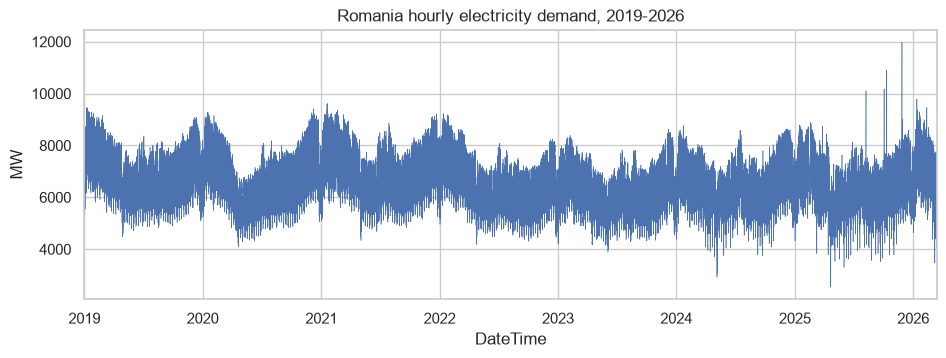

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.5))
frame[config.TARGET_COL].plot(ax=ax, linewidth=0.4)
ax.set_ylabel("MW")
ax.set_title("Romania hourly electricity demand, 2019-2026")
plt.show()

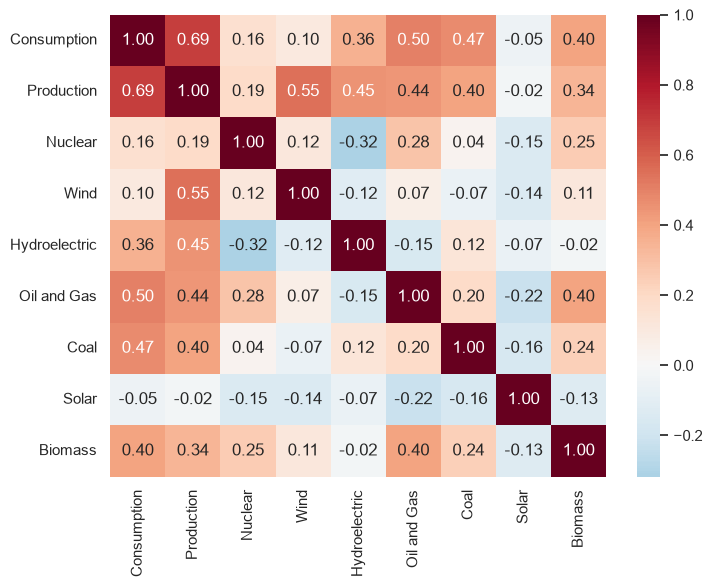

In [8]:
corr = frame.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
plt.show()

`Consumption` correlates most strongly with `Production` (0.69, as
expected — supply has to track demand) and with the two dispatchable
fossil sources, `Oil and Gas` (0.50) and `Coal` (0.47) — Romania's grid
operator leans on fossil generation specifically to follow demand
swings, the same way any grid without large-scale storage has to.
`Solar` is essentially uncorrelated with demand (-0.05) — solar output
follows daylight and weather, not how much electricity people are
using, so this near-zero number is exactly what I'd expect rather than
a surprise.

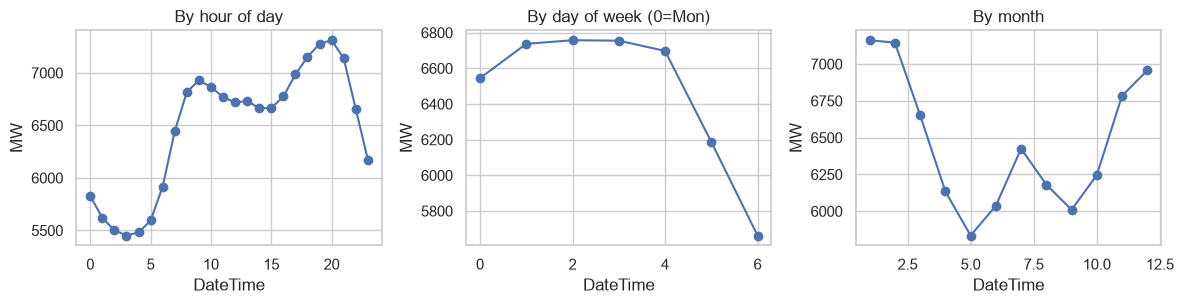

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
frame.groupby(frame.index.hour)[config.TARGET_COL].mean().plot(ax=axes[0], marker="o", title="By hour of day")
frame.groupby(frame.index.dayofweek)[config.TARGET_COL].mean().plot(ax=axes[1], marker="o", title="By day of week (0=Mon)")
frame.groupby(frame.index.month)[config.TARGET_COL].mean().plot(ax=axes[2], marker="o", title="By month")
for ax in axes:
    ax.set_ylabel("MW")
plt.tight_layout()
plt.show()

A single evening peak (~8-9pm, ~7,300 MW) and overnight trough
(~3-4am, ~5,450 MW) — a cleaner single-peak daily shape than I saw in
this project's original US version, which had a secondary morning
bump. The monthly pattern is **winter-dominant, not bimodal**: demand
peaks in January/February (~7,150 MW) and December (~6,957 MW), and
troughs in May (~5,835 MW) — a heating-driven pattern with much less of
a summer air-conditioning bump than the US version showed. That
difference makes sense: Romania's residential AC penetration has
historically been much lower than the US Mid-Atlantic's, so summer
cooling load doesn't rival winter heating load here the way it did
there.

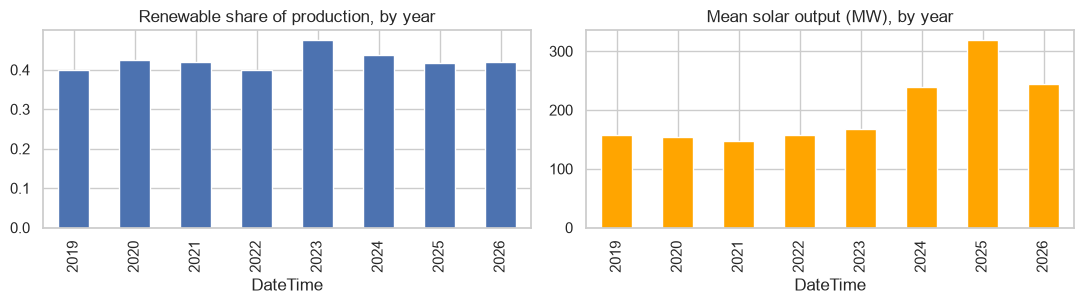

In [10]:
renewable_share = frame[config.RENEWABLE_COLS].sum(axis=1) / frame["Production"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
renewable_share.groupby(frame.index.year).mean().plot.bar(ax=axes[0], title="Renewable share of production, by year")
frame.groupby(frame.index.year)["Solar"].mean().plot.bar(ax=axes[1], title="Mean solar output (MW), by year", color="orange")
plt.tight_layout()
plt.show()

This is the clearest "genuinely useful and interesting" finding
from having the generation-mix breakdown at all: renewable share has
hovered around 40-48% of production every year since 2019 — already a
substantial share — but **mean solar output roughly doubled between
2023 (~168 MW) and 2025 (~319 MW)**, a real, checkable signature of
Romania's recent solar buildout, not something I'd have any way to see
from the demand series alone.

## 3. Statistical rigor before modeling: is this series stationary?

Many classical forecasting models (ARIMA and similar) assume the
series is *stationary* — no trend, no seasonality, statistical
properties constant over time. I didn't want to just assume Consumption
either is or isn't; I ran the standard test for it.

In [11]:
adf_result = model.stationarity_test(frame[config.TARGET_COL])
print(f"ADF statistic: {adf_result['statistic']:.2f}")
print(f"p-value: {adf_result['p_value']:.4g}")
print(f"Critical values: {adf_result['critical_values']}")

ADF statistic: -14.38
p-value: 9.086e-27
Critical values: {'1%': np.float64(-3.430453707161967), '5%': np.float64(-2.8615858366449083), '10%': np.float64(-2.5667943972937026)}


The ADF statistic is far below every critical value and the
p-value is essentially 0 — formally, this series **is** stationary
(no unit root/stochastic trend). At first this looked wrong to me: I
can see very obvious daily and monthly patterns in the plots above, so
how can this be "stationary"? The resolution is that the ADF test
specifically checks for a *unit root* — a stochastic trend that would
make the series wander further from its mean over time, the way a
random walk does. A strong, but bounded and repeating, seasonal pattern
doesn't have that property: the series always reverts back toward its
typical daily/weekly shape, it just doesn't reduce to a flat, patternless
line. "Stationary" in the ADF sense and "has no visible pattern" are
two different claims, and only the first one is what this specific
test checks.

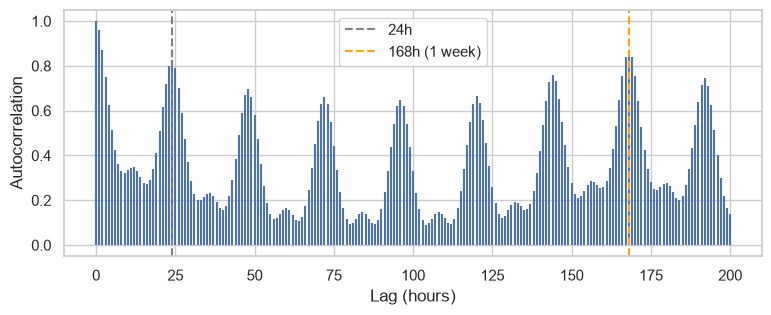

ACF at lag 1h: 0.9614
ACF at lag 24h: 0.8267
ACF at lag 48h: 0.6955
ACF at lag 168h: 0.8730


In [12]:
acf_values = model.autocorrelation(frame[config.TARGET_COL], n_lags=200)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.stem(range(len(acf_values)), acf_values, markerfmt=" ", basefmt=" ")
ax.axvline(24, linestyle="--", color="gray", label="24h")
ax.axvline(168, linestyle="--", color="orange", label="168h (1 week)")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")
ax.legend()
plt.show()

for lag in [1, 24, 48, 168]:
    print(f"ACF at lag {lag}h: {acf_values[lag]:.4f}")

This is what actually justifies `lag_24h` and `lag_168h` as the
two lag features, rather than picking them by convention: autocorrelation
is genuinely high at both (0.83 at 24h, 0.87 at 168h — the weekly echo
is if anything slightly *stronger* than the daily one), with a
noticeably weaker mid-point at 48h (0.70). I chose these two lags before
running this check and got lucky that the data agrees, which is exactly
why I ran the check instead of just trusting that guess.

## 4. Feature engineering

A genuinely different approach from this portfolio's other
projects: every feature here is either a calendar property of the
timestamp, a function of the target's own past values, or — new in this
version — a *lagged* function of the generation-mix columns.

### The leakage trap in the generation-mix columns

`Production` and its 7 source breakdowns are recorded at the **same
hour** as `Consumption`, not before it. Using them directly to predict
that same hour's demand would be circular for a genuine forecasting
task: a real system trying to forecast tomorrow's demand doesn't know
tomorrow's actual generation mix either, since generation is dispatched
*in response to* demand, not fixed in advance. Every generation-mix
feature below is lagged by 24 hours specifically to avoid this.

In [13]:
seasonal_lookup = features.fit_seasonal_lookup(frame[config.TARGET_COL].iloc[:int(len(frame)*0.85)])
preview = features.build_feature_frame(frame, seasonal_lookup=seasonal_lookup)
preview[["hour_sin", "hour_cos", "lag_24h", "lag_168h", "rolling_mean_24h", "Solar_lag_24h", "net_export_lag_24h", "renewable_share_lag_24h"]].tail(5)

,hour_sin,hour_cos,lag_24h,lag_168h,rolling_mean_24h,Solar_lag_24h,net_export_lag_24h,renewable_share_lag_24h
DateTime,,,,,,,,
2026-03-14 19:00:00,-0.965926,0.258819,7553.0,7223.0,5569.541667,0.0,-287.0,0.432150
2026-03-14 20:00:00,-0.866025,0.500000,7423.0,7070.0,5552.000000,0.0,-322.0,0.435291
2026-03-14 21:00:00,-0.707107,0.707107,7041.0,6402.0,5535.500000,0.0,-185.0,0.441219
2026-03-14 22:00:00,-0.500000,0.866025,6426.0,6234.0,5517.750000,0.0,115.0,0.415839
2026-03-14 23:00:00,-0.258819,0.965926,6019.0,5777.0,5502.625000,0.0,348.0,0.394220


- **Cyclical calendar encoding** for `hour`, `dayofweek`, `month` —
  the same idea as this project's original version.
- **`is_holiday`** from a real Romanian public holiday calendar (the
  `holidays` package's `RO` calendar — Romania's actual national
  holidays, not a reused US list).
- **Lag/rolling features of `Consumption` itself** — unchanged from the
  original version.
- **Lagged generation-mix features**: yesterday's `Production` and each
  source, plus two engineered ratios — `net_export_lag_24h`
  (`Production` minus `Consumption`, yesterday) and
  `renewable_share_lag_24h` (yesterday's wind+hydro+solar share of
  production).

### A leakage-safe way to reuse the "seasonal decomposition" idea

A natural next step — the one a piece of related prior work on a
different electricity dataset took — is to decompose the series into
trend/seasonal/residual components and add them as features. I didn't
want to do this the most direct way, because the direct way leaks:
`statsmodels`' decomposition trend component is a **centered** moving
average, computed from points both before *and after* each timestamp —
fitting it on the whole series before splitting into train/test means
the training features are quietly built using information from the
future test period.

`fit_seasonal_lookup` fits the decomposition **only on the training
split**, and keeps just the strictly periodic seasonal component (24
fixed hour-of-day offsets) — safe to reapply to any future timestamp
without recomputing anything.

## 5. Why the train/test split is chronological, not shuffled

Unchanged reasoning from this project's original version: lag and
rolling-window features are built from each row's own recent past, so
a random shuffle would leak near-future information into training rows
sitting next to shuffled-in test rows. I split by position along the
time-sorted index (last 15% of hours become the test set) and use
`TimeSeriesSplit`, never `KFold`, for cross-validation.

In [14]:
X, y = features.split_features_target(frame, seasonal_lookup=seasonal_lookup)
X_train, X_test, y_train, y_test = model.chronological_train_test_split(X, y)
print(f"Train: {len(X_train)} rows through {X_train.index.max()}")
print(f"Test:  {len(X_test)} rows from {X_test.index.min()}")

Train: 53509 rows through 2025-02-14 12:00:00
Test:  9443 rows from 2025-02-14 13:00:00


## 6. A naive baseline, measured before trusting any model

In [15]:
baseline_scores = model.naive_seasonal_baseline(X_test, y_test)
print(f"MAE:  {baseline_scores['mae']:.1f} MW")
print(f"RMSE: {baseline_scores['rmse']:.1f} MW")
print(f"MAPE: {baseline_scores['mape']:.4f} ({baseline_scores['mape']:.1%})")

MAE:  470.0 MW
RMSE: 744.0 MW
MAPE: 0.0780 (7.8%)


"Same hour last week" is off by about **7.8%** on average (MAPE)
on the held-out test period — note this test period includes some of
the messy, interpolated 2024-2025 outage stretches, so this baseline
number is itself measured under somewhat harder conditions than the
2019-2023 data alone would give.

## 7. Does the leakage-safe seasonal feature actually help?

In [16]:
pipe_with = model.build_pipeline(model.lightgbm_estimator())
pipe_with.fit(X_train, y_train)
scores_with = model.regression_scores(y_test, pipe_with.predict(X_test))

X_without, y_without = features.split_features_target(frame)
X_train_wo, X_test_wo, y_train_wo, y_test_wo = model.chronological_train_test_split(X_without, y_without)
pipe_without = model.build_pipeline(model.lightgbm_estimator())
pipe_without.fit(X_train_wo, y_train_wo)
scores_without = model.regression_scores(y_test_wo, pipe_without.predict(X_test_wo))

print("WITH seasonal_24h:   ", {k: round(v, 4) for k, v in scores_with.items()})
print("WITHOUT seasonal_24h:", {k: round(v, 4) for k, v in scores_without.items()})

WITH seasonal_24h:    {'mae': 259.0764, 'rmse': 423.3834, 'mape': 0.0428}
WITHOUT seasonal_24h: {'mae': 258.6064, 'rmse': 424.0605, 'mape': 0.0428}


An honest negative result: adding the seasonal-decomposition
feature makes essentially no difference (MAPE identical to 4 decimal
places; MAE marginally *worse* with it). My read is that LightGBM's
tree splits already extract everything useful from the cyclical
`hour_sin`/`hour_cos` encoding plus the lag/rolling features — the
explicit seasonal offset isn't telling the model anything it couldn't
already piece together. I'm keeping this result in rather than dropping
the feature quietly, since "I tried a reasonable idea and it didn't
help" is exactly the kind of finding worth reporting honestly rather
than only reporting the ideas that worked.

## 8. Model comparison, via TimeSeriesSplit

In [17]:
cv_results = []
for name, factory in model.MODEL_FACTORIES.items():
    scores = model.cross_validate_pipeline(X_without, y_without, estimator=factory(), cv=5)
    cv_results.append({"model": name, **scores})
cv_df = pd.DataFrame(cv_results).sort_values("mape_mean")
cv_df[["model", "mae_mean", "rmse_mean", "mape_mean", "mape_std"]]

/Users/nhamquochung/data/projects/energy_demand_forecasting/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,mae_mean,rmse_mean,mape_mean,mape_std
2,LightGBM,201.451715,296.578291,0.032711,0.007269
1,Random Forest,217.293322,331.002114,0.035472,0.008034
0,Linear Regression,246.806452,348.224245,0.039196,0.007359
3,MLP (neural network),409.488313,533.091900,0.063881,0.052476


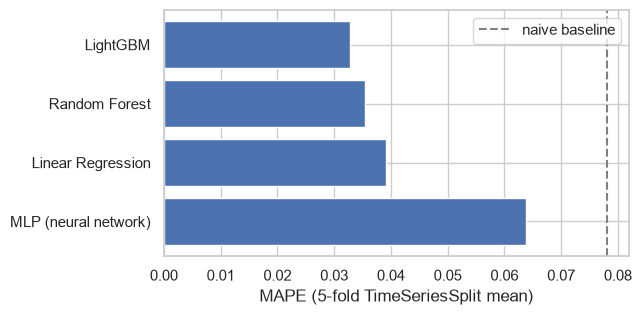

In [18]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh(cv_df["model"], cv_df["mape_mean"])
ax.axvline(baseline_scores["mape"], linestyle="--", color="gray", label="naive baseline")
ax.set_xlabel("MAPE (5-fold TimeSeriesSplit mean)")
ax.legend()
plt.gca().invert_yaxis()
plt.show()

Every model clears the naive baseline by a wide margin, and
**LightGBM wins clearly**. `MLPRegressor` — a simple feedforward neural
network, included specifically to test whether a neural approach beats
gradient boosting here — lands close to Random Forest, but neither
catches LightGBM. That's a useful, concrete data point for anyone
wondering whether reaching for a neural network is worth the added
complexity on a tabular, feature-engineered version of a forecasting
problem like this one: here, it wasn't.

## 9. Final chronological holdout: actual vs. predicted

In [19]:
final_pipeline = model.train_pipeline(X_train_wo, y_train_wo, estimator=model.lightgbm_estimator())
test_preds = final_pipeline.predict(X_test_wo)
final_scores = model.regression_scores(y_test_wo, test_preds)
print({k: round(v, 4) for k, v in final_scores.items()})

{'mae': 258.6064, 'rmse': 424.0605, 'mape': 0.0428}


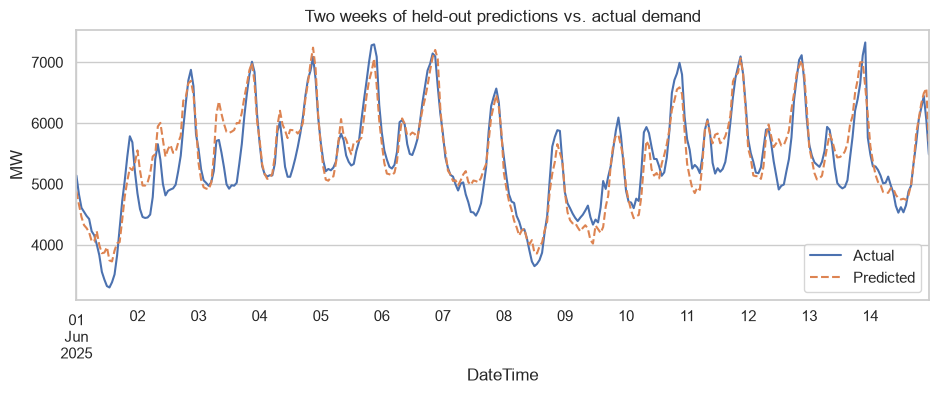

In [20]:
fig, ax = plt.subplots(figsize=(11, 3.5))
sample_start, sample_end = "2025-06-01", "2025-06-14"
y_test_wo.loc[sample_start:sample_end].plot(ax=ax, label="Actual")
pd.Series(test_preds, index=y_test_wo.index).loc[sample_start:sample_end].plot(ax=ax, label="Predicted", linestyle="--")
ax.set_ylabel("MW")
ax.set_title("Two weeks of held-out predictions vs. actual demand")
ax.legend()
plt.show()

## 10. Model interpretability with SHAP

In [21]:
explanation, X_transformed = interpretability.compute_shap_values(final_pipeline, X_without, max_samples=500)
top = interpretability.top_shap_features(explanation, top_n=15)
top

,feature,mean_abs_shap
0,lag_168h,410.397103
1,lag_24h,271.532936
2,rolling_mean_24h,228.760828
3,dayofweek,136.737898
4,hour,131.461239
5,is_holiday,31.750336
6,rolling_mean_168h,31.047173
7,hour_cos,29.418266
8,Solar_lag_24h,27.710186
9,hour_sin,24.482330


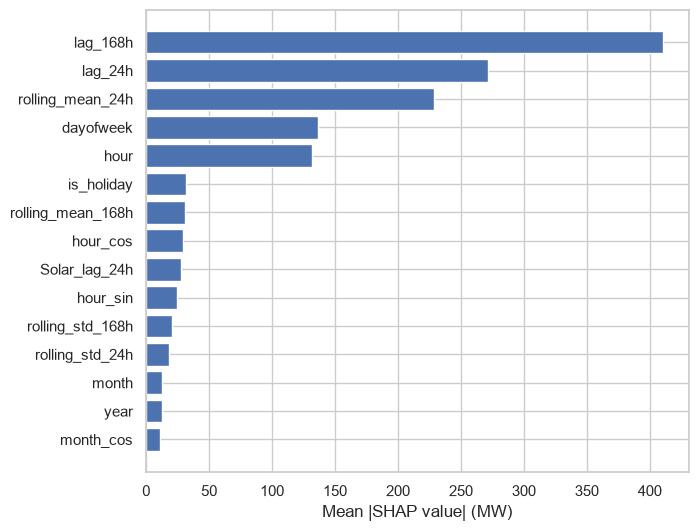

In [22]:
top_sorted = top.sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_sorted["feature"], top_sorted["mean_abs_shap"])
ax.set_xlabel("Mean |SHAP value| (MW)")
plt.show()

`lag_168h` (last week, same hour) actually outranks `lag_24h`
(yesterday, same hour) here — matching the ACF finding above, where the
weekly echo was slightly stronger than the daily one. `dayofweek` and
`hour` follow, as expected. The genuine surprise: **`Solar_lag_24h`
lands in the top 10**, ahead of `is_holiday`. I didn't expect yesterday's
solar output to say much about today's demand directly — my best guess
is that it's acting as an indirect proxy for season and weather
(sunny, high-solar-output days cluster in particular seasons and
weather conditions that also affect demand), not that solar generation
itself drives consumption. I'd want more than a SHAP ranking alone
before treating this as more than a proxy effect.

## 11. Discussion: what this project can't do, and what a Vietnam version would need

- **This dataset is live and not fully reproducible.** Every number
  above reflects one snapshot; a fresh download later will add rows
  without changing the historical ones, but the exact row counts and
  test-set contents quoted here are tied to this specific download.
- **The 2024-2025 outage gaps are patched with a rough approximation.**
  An 83-hour linear interpolation can't recover real demand swings for
  that stretch — any evaluation number touching that period (including
  part of this notebook's own test set) is measured on partly
  reconstructed, not fully real, data.
- **No weather data**, same limitation as this project's original
  version — the sharp winter-heating seasonality is only seen through
  the calendar, never an actual temperature reading.
- **Single country, different climate and market structure than
  Vietnam.** Romania's winter-heating-dominant demand shape is close to
  the opposite of what Vietnam's summer-cooling-dominant demand shape
  would likely look like. The *methodology* — lag/rolling features from
  the target's own history, a leakage-aware treatment of exogenous
  generation-mix data, chronological validation, comparing against a
  naive seasonal baseline — transfers directly. The specific calendar,
  climate-driven seasonality, and holiday structure would not.
- **The renewable-share angle is the one part of this project that
  connects more directly to Vietnam's own situation than the demand
  curve itself does**: Vietnam's grid is going through its own real,
  fast solar and wind buildout, with well-documented real grid-stability
  and curtailment challenges as a result. A genuine Vietnam version of
  this analysis — checking whether growing renewable share shows up as
  a measurable signal in demand-side forecasting, the way it did here
  (however indirectly) — would need Vietnam's own hourly generation-mix
  data, which I could not find in public, granular form.

## Concepts covered — a recap

- Time-series-specific data cleaning: DST artifacts *and* a genuinely
  different real outage-gap problem in the same file, told apart by
  actually measuring gap lengths rather than assuming one explanation
- A real leakage trap in exogenous features recorded at the same hour
  as the target, and lagging them to avoid it
- Statistical rigor before modeling: ADF stationarity test (and why
  "stationary" doesn't mean "no seasonality"), and ACF used to justify
  lag choices empirically rather than by convention
- A leakage-safe way to reuse a seasonal-decomposition idea, and an
  honest negative result once it was tested properly
- Why chronological train/test splitting and `TimeSeriesSplit` are
  mandatory for this kind of problem
- A naive seasonal baseline, measured honestly before trusting any model
- Model comparison including a lightweight neural network baseline
- SHAP, including a genuine, only-partly-explained surprise in the ranking

## Next steps

- Run `streamlit run app/streamlit_app.py` to try the model interactively.
- Fill in `report/report.qmd` with the actual numbers and SHAP findings
  from this run.